# Identify CSTR-separator SS using PARSIM-K


In [36]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np
import sys
import joblib
from sklearn.preprocessing import StandardScaler

from sippy_unipi import system_identification
from sippy_unipi import functionsetSIM as fsetSIM

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

import models
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the identification dataset


In [37]:
# Plant used to generate ../data/cstr_separator_ident.npz
CSTR = models.CSTRSeparator()


In [38]:
# Load pre-generated CSTR-separator identification data
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10] (F20, Fr held at nominal)
data = np.load("../data/cstr_separator_ident.npz", allow_pickle=True)
sim = {"Y": np.array(data["Y"], dtype=float), "U": np.array(data["U"], dtype=float)}
print("Loaded", data.files)
print("Y", sim["Y"].shape, list(data["y_names"]))
print("U", sim["U"].shape, list(data["u_names"]))
print("Ts =", float(data["Ts"]), "step_time =", int(data["step_time"]), "no_steps =", int(data["no_steps"]))


Loaded ['Y', 'Y_clean', 'U', 'X', 'U_plant', 'Ts', 'step_time', 'no_steps', 'y_names', 'u_names', 'x0', 'u_nom', 'mv_constraints', 'noise_frac', 'noise_sigma', 'noise_seed', 'n_train_noise']
Y (10000, 4) [np.str_('T1'), np.str_('T2'), np.str_('T3'), np.str_('xB3')]
U (10000, 4) [np.str_('Q1'), np.str_('Q2'), np.str_('Q3'), np.str_('F10')]
Ts = 1.0 step_time = 100 no_steps = 100


In [39]:
# Range-aware measurement noise: sigma_i = noise_frac * train range of channel i
add_noise = True
noise_frac = 0.01
n_train_noise = 7200
if add_noise:
    np.random.seed(42)
    y_range = sim["Y"][:n_train_noise].max(axis=0) - sim["Y"][:n_train_noise].min(axis=0)
    sigma = noise_frac * y_range
    sim["Y"] = sim["Y"] + np.random.normal(0.0, 1.0, size=sim["Y"].shape) * sigma
    print("Noise std (1% of train range):")
    for name, s, r in zip(data["y_names"], sigma, y_range):
        print(f"  {name}: sigma={s:.4g}  (range={r:.4g})")


Noise std (1% of train range):
  T1: sigma=0.3266  (range=32.66)
  T2: sigma=0.342  (range=34.2)
  T3: sigma=0.3815  (range=38.15)
  xB3: sigma=0.003645  (range=0.3645)


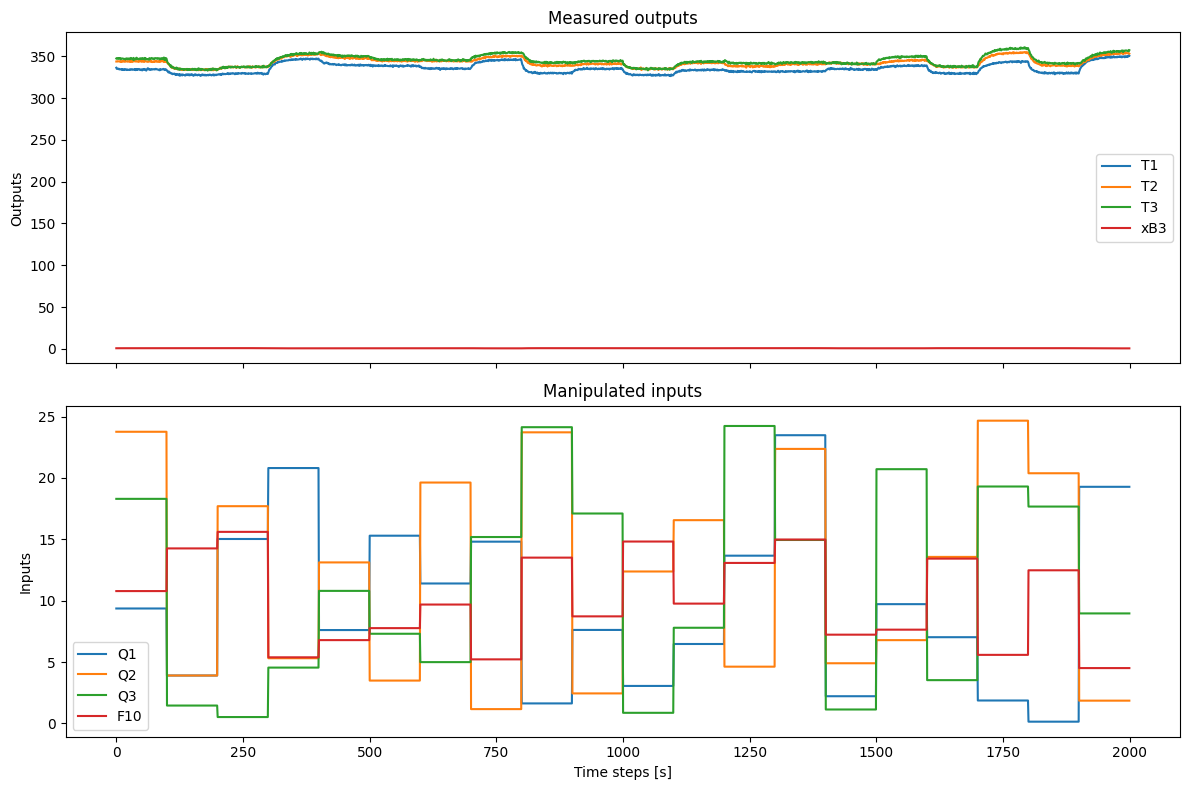

In [40]:
part = 2000
y_names = ["T1", "T2", "T3", "xB3"]
u_names = ["Q1", "Q2", "Q3", "F10"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for i, name in enumerate(y_names):
    axes[0].plot(sim["Y"][:part, i], label=name)
axes[0].set_ylabel("Outputs")
axes[0].set_title("Measured outputs")
axes[0].legend()

for i, name in enumerate(u_names):
    axes[1].plot(sim["U"][:part, i], label=name)
axes[1].set_xlabel("Time steps [s]")
axes[1].set_ylabel("Inputs")
axes[1].set_title("Manipulated inputs")
axes[1].legend()
plt.tight_layout()
plt.show()


In [41]:
# Fit scalers on the training split (same convention as Koopman notebooks)
n_train, n_dev = 7200, 1600
train_raw = {key: value[:n_train] for key, value in sim.items()}
dev_raw = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test_raw = {key: value[n_train + n_dev:] for key, value in sim.items()}

scaler = StandardScaler()
scaler.fit(train_raw["Y"])
joblib.dump(scaler, "../data/scaler_cstr_separator.pkl")

scalerU = StandardScaler()
scalerU.fit(train_raw["U"])
joblib.dump(scalerU, "../data/scalerU_cstr_separator.pkl")


['../data/scalerU_cstr_separator.pkl']

In [42]:
train_sim = {
    "Y": scaler.transform(train_raw["Y"]),
    "U": scalerU.transform(train_raw["U"]),
}
dev_sim = {
    "Y": scaler.transform(dev_raw["Y"]),
    "U": scalerU.transform(dev_raw["U"]),
}
test_sim = {
    "Y": scaler.transform(test_raw["Y"]),
    "U": scalerU.transform(test_raw["U"]),
}
print("train", train_sim["Y"].shape, "dev", dev_sim["Y"].shape, "test", test_sim["Y"].shape)


train (7200, 4) dev (1600, 4) test (1200, 4)


## Identification using PARSIM-K


In [43]:
y_tot = train_sim["Y"].copy()
U = train_sim["U"].T.copy()


In [44]:
sys_id = system_identification(y_tot.copy(), U.copy(), "PARSIM-K", SS_fixed_order=10)


/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/sippy_unipi/functionsetSIM.py:53: RuntimeWarning: divide by zero encountered in matmul
  Vn = (eps @ eps) / (max(y.shape))  # @ is dot
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/sippy_unipi/functionsetSIM.py:53: RuntimeWarning: overflow encountered in matmul
  Vn = (eps @ eps) / (max(y.shape))  # @ is dot
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/sippy_unipi/fu

In [45]:
sys_id.A


array([[ 9.46250077e-01,  1.86280057e-03, -8.07321188e-02,
        -3.71984684e-02,  1.88188868e-02, -3.57543544e-02,
        -1.16997316e-02, -2.99077344e-03,  1.49836865e-02,
        -3.22958476e-03],
       [-4.26696176e-03,  9.49884144e-01, -2.51358417e-03,
         3.60516853e-02, -7.35382828e-02, -6.17425601e-02,
        -4.23970923e-02, -4.44869458e-02, -1.27557982e-03,
        -5.77264534e-03],
       [ 1.45138012e-02, -1.02725357e-03,  9.63781970e-01,
         1.46937265e-02, -2.96468623e-02, -4.77510556e-03,
        -1.18880986e-01,  4.89169325e-02,  2.14536766e-02,
        -1.67910798e-02],
       [-1.87714057e-02, -5.27762564e-03, -9.28107936e-03,
         9.65176457e-01,  3.71709823e-02, -2.51558688e-03,
         6.06437094e-02, -9.24279533e-03, -1.20419893e-02,
         1.79539637e-02],
       [ 3.15239909e-02, -5.99137451e-03,  1.15873742e-02,
         4.14881541e-02,  9.01680412e-01, -1.16163650e-02,
        -1.35336007e-01, -5.77886111e-02, -5.78220767e-02,
        -2.

In [46]:
append = "_cstr_separator_parsimK"
np.save("../data/A" + append + ".npy", sys_id.A)
np.save("../data/B" + append + ".npy", sys_id.B)
np.save("../data/C" + append + ".npy", sys_id.C)
np.save("../data/D" + append + ".npy", sys_id.D)


In [47]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    test_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ test_sim["Y"][0].reshape(-1, 1),
)


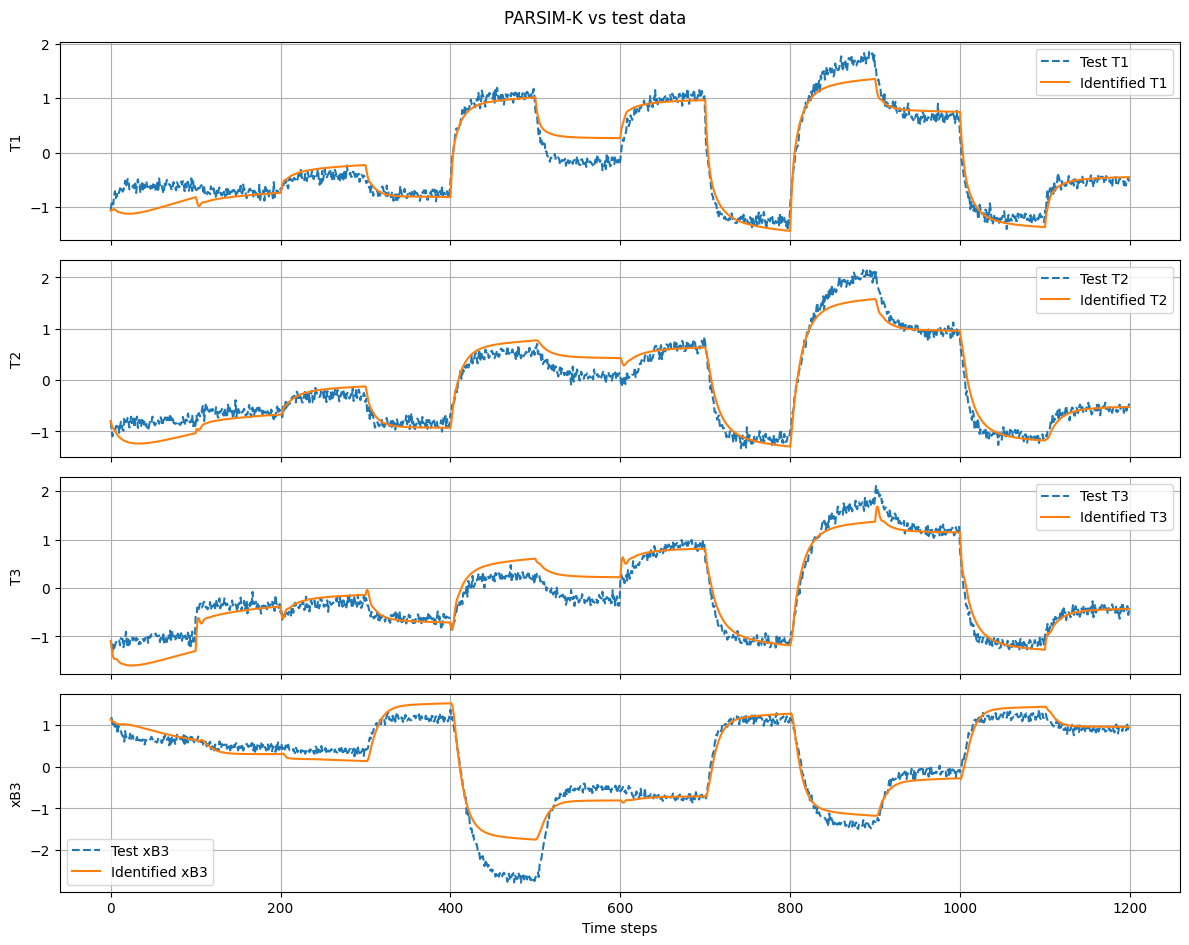

Test MAE per output: [0.16456556 0.16651827 0.19058715 0.21575955]
Sum of MAE: 0.7374305340424351


In [48]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = test_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(test_sim["Y"][:, i], label=f"Test {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs test data")
plt.tight_layout()
plt.show()

test_mae = np.mean(np.abs(test_sim["Y"].T - yid), axis=1)
print("Test MAE per output:", test_mae)
print("Sum of MAE:", np.sum(test_mae))


In [49]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    train_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ train_sim["Y"][0].reshape(-1, 1),
)


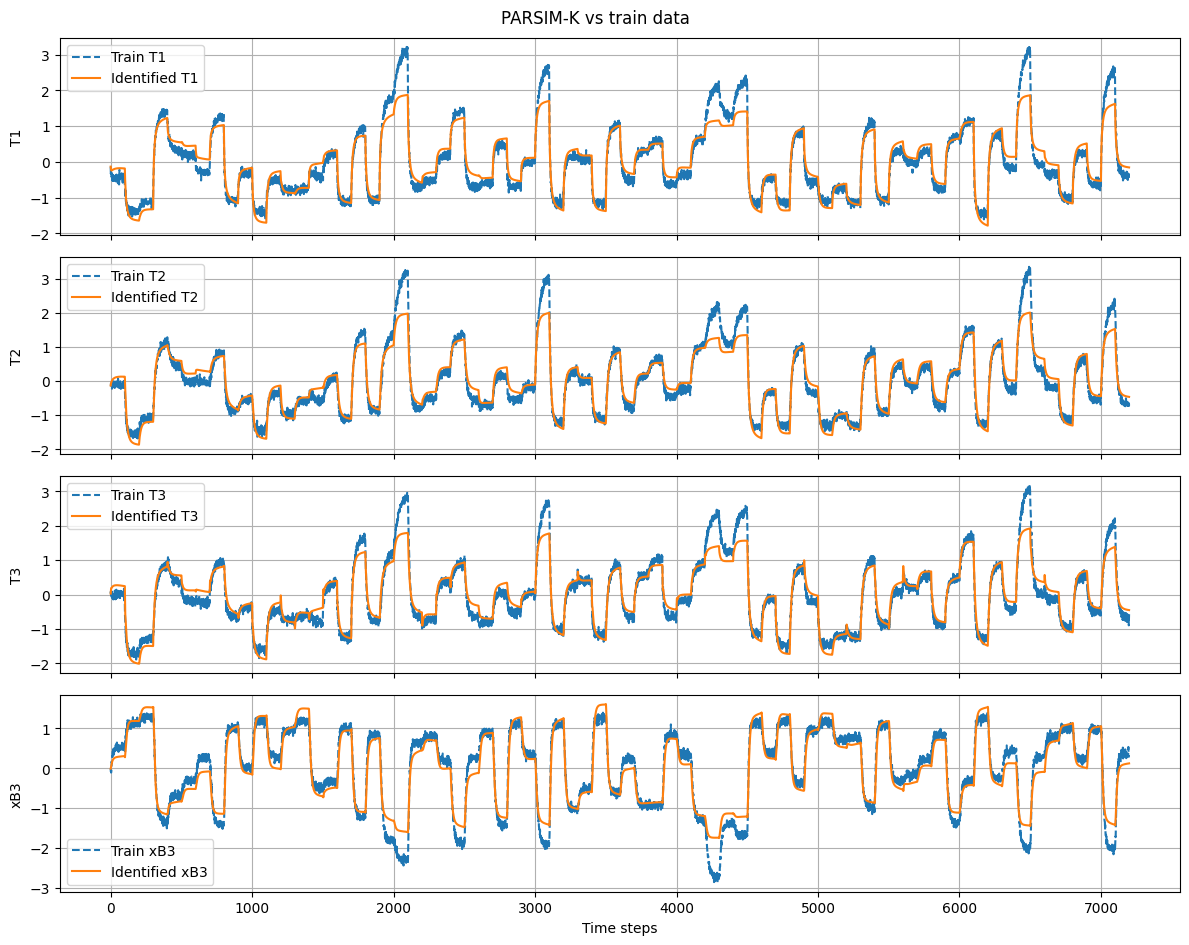

In [50]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = train_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(train_sim["Y"][:, i], label=f"Train {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs train data")
plt.tight_layout()
plt.show()
